# AXM - MLE/DS Role
Saira Chawla

In [184]:
# importing necessary libraries
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
import arviz as az

# importing from PyMC
from pymc_marketing.mmm import MMM, GeometricAdstock, LogisticSaturation
from pymc_marketing.mmm.transformers import geometric_adstock, logistic_saturation
from pymc_marketing.prior import Prior
from pymc_marketing.mmm.budget_optimizer import optimizer_xarray_builder

# misc functions
from sklearn.metrics import r2_score

### Objective 1
Generate a synthetic marketing and sales dataset as a way to evaluate and validate
your modelling approach.

In [4]:
cols_to_keep = []

In [6]:
def generate_dates(min_date, max_date, time_period):
    ## this function creates a range of dates with interval periods by either day or week and returns that in a dataframe
    d = None
    if time_period == "week":
        d = pd.DataFrame(data={'date': pd.date_range(start=min_date, end=max_date, freq="W-MON")})
    elif time_period == "day":
        d = pd.DataFrame(data={'date': pd.date_range(start=min_date, end=max_date, freq="D")})

    cols_to_keep.append('date')

    print(f"Number of observations: {d.shape[0]}")
    return d

In [8]:
df = generate_dates(pd.to_datetime("2021-01-01"), pd.to_datetime("2024-05-01"), 'week')
df.head()

Number of observations: 174


,date
0,2021-01-04
1,2021-01-11
2,2021-01-18
3,2021-01-25
4,2021-02-01


In [10]:
def generate_control_events(df, days):
    ## this function modifies a df by adding control variables that signify a reason for a remarkable peak in sales (i.e. black friday, launch of a new product, etc.)
    for i in np.arange(0, len(days)):
        df[f"event_{i+1}"] = (df['date'] == days[i]).astype(float)
        #cols_to_keep.append(f"event_{i+1}")
    return df

In [12]:
df = generate_control_events(df, ['2021-01-04', '2023-11-27']) 
# assuming 2021-01-04 was a launch of the product 
# black friday in 2023 was actual on the 24th but for demo purposes, using the 27th
df.head()

,date,event_1,event_2
0,2021-01-04,1.0,0.0
1,2021-01-11,0.0,0.0
2,2021-01-18,0.0,0.0
3,2021-01-25,0.0,0.0
4,2021-02-01,0.0,0.0


In [14]:
def generate_trend_seasonal_components(df, time_period):
    # this function adds synthetic trend and seasonal components to the dataframe
    # in the future, this function can be further parameterized based off prior information of the trend/climate, but for 
    # demo purposes, i am assuming trends and seasonality are the same across all markets 
    if time_period == 'week':
        df['trend'] = (np.linspace(0, 52, num=len(df)) + 10) ** (1/4) - 1  # formula modified from pymc-marketing mmm example 
        df['seasonality'] = 0.25 * np.sin(2 * np.pi * df.index / 52) # formula modified from towards data science article
    elif time_period == 'day':
        df['trend'] = (np.linspace(0, 365, num=len(df)) + 10) ** (1/4) - 1
        df['seasonality'] = 0.25 * np.sin(2 * np.pi * df.index / 365)
    return df 

The line of code below is adding gdp as an economic indicator. This is not in a function as the values (22.0 and 0.00165) are based off the start time and end time of the time period I am using in my example. This could be parameterized into a function by connecting with an API that pulls starting GDP based off the first start time and then estimates growth rate between start time and end time.

In [17]:
df['gdp'] = 22.0 * (1 + 0.00165) ** np.arange(len(df)) + np.random.normal(0, 0.05, len(df)) # GDP in $Trillions
    # 22.0 represents starting GDP in trillions
    # chatgpt estimates that monthly growth rate was 0.00165 based off an approximate of 2% annual gdp growth 
    # added random noise to simulate small economic peaks and dips 
df["gdp_scaled"] = (df["gdp"] - df["gdp"].min()) / (df["gdp"].max() - df["gdp"].min())
    # using a scaled GDP to understand the variance within the given time range

In [19]:
df = generate_trend_seasonal_components(df, 'week')
df.head() 

,date,event_1,event_2,gdp,gdp_scaled,trend,seasonality
0,2021-01-04,1.0,0.0,21.984121,0.000000,0.778279,0.000000
1,2021-01-11,0.0,0.0,22.065142,0.011239,0.791494,0.030134
2,2021-01-18,0.0,0.0,22.074004,0.012469,0.804423,0.059829
3,2021-01-25,0.0,0.0,22.120371,0.018901,0.817079,0.088651
4,2021-02-01,0.0,0.0,22.096681,0.015615,0.829477,0.116181


Below I am plotting a time series of trend, GDP scaled, and seasonality to confirm that the lines represent a reasonable relationship of those variables across time.

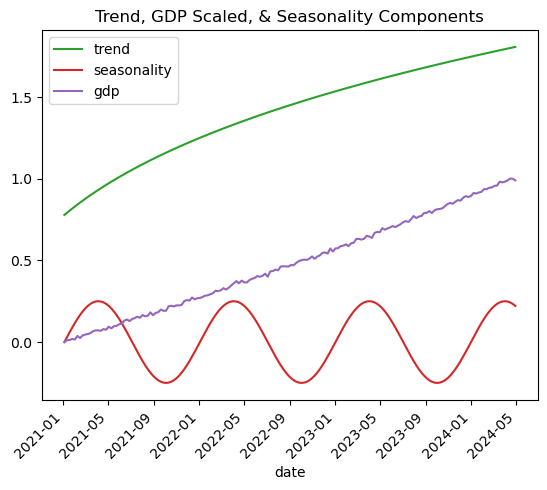

In [22]:
fig, ax = plt.subplots()
sns.lineplot(x="date", y="trend", color="C2", label="trend", data=df, ax=ax)
sns.lineplot(
    x="date", y="seasonality", color="C3", label="seasonality", data=df, ax=ax
)
sns.lineplot(
    x="date", y="gdp_scaled", color="C4", label="gdp", data=df, ax=ax
)
ax.legend(loc="upper left")
ax.set(title="Trend, GDP Scaled, & Seasonality Components", xlabel="date", ylabel=None)
plt.xticks(rotation=45, ha='right');

In [24]:
def generate_media_data(df, x1_thres = 0.85, x2_thres = 0.7, a1=0.7, a2 = 0.4, l1 = 2.0, l2 = 5.0, max_lag=6):
    ## this function adds media costs data to the df, specifically to understand exposure levels of each channel 
    ## x1 and x2 - represent media channels spend and the transformations approximate exposure levels of that channel expenditure
    ## assumption: looking across 2 types of media channels - (x1) ads on tvs/radios, (x2) digital campaigns on social media such as tiktok (i.e. influencers)
    ## i am not including search as a 3rd type of media channel b/c it can be confounding with tvs/radios ads as they may ignite an increase 
    ## in search numbers and in a more complex model, we can use search as an estimate for demand 
    ## this assumption can be tweaked in the future to account for more or less channels, but for demonstration purposes, i am sticking with 2
    
    seed = 42
    np.random.seed(seed)
    n = df.shape[0]

    x1 = np.random.uniform(low=0.0, high=1.0, size = n)
    x2 = np.random.uniform(low=0.0, high=1.0, size = n)
    
    df['x1'] = np.where(x1 > x1_thres, x1, 0) # intuition: tv/radio ads require a minimum budget commitment to be notieceable; it takes a certain 
                                          # threshold of expenditure on tv ads to generate impact
    df['x2'] = np.where(x2 > x2_thres, x2, x2/3) # intuition: social media campaigns still have some effect at lower levels of engagement due to 
                                            # the affects of technology - ability to immediately click on campaign to view product/service; 
                                            # minimal views still gain impressions 
                                            # i.e. instagram, tiktok shop, hyperlink on facebook
                                            # furthermore, x2/3 models dimisnishing returns in regards to small ad spend not receiving the 
                                            # full impact;

    ## carryover effect - adstock: delay between an ad being seen and the response to it; a lagged/delayed/decaying effect of ad spend; 
    ## there is a gradual decrease of carryover impact; impact isn't instantaneous or one-time spike 
    alpha1 = a1 # assumption: tv/radio ads have a strong carryover effect due to broad reach of viewers and are more impactful as there is less 
                 # content being consumed in the same amount of time as if it were consumed on social media, thus there is a more sustained impact 
                 # (i still remember the diy slushy kit ad from Disney Channel when i was younger)
                 # there is still a gradual reduction but these tv/radio ads are repetitive
    alpha2 = a2 # assumption: social media ads/campaigns are shorter-lived and prioritize real-time engagement and immediate responses (i.e. tiktok shop)
                 # however, lives, shares, and comments can create momentum for the brand (i.e. a tiktok goes viral)
                 # however, the impact tends to decay faster, especially due to how much media is being consumed in a small time period and the focus
                 # is on immediate actions 
    df['x1_adstock'] = geometric_adstock(x=df['x1'].to_numpy(), alpha = alpha1, l_max = max_lag, normalize=True).eval().flatten()
    df['x2_adstock'] = geometric_adstock(x=df['x2'].to_numpy(), alpha = alpha2, l_max = max_lag, normalize=True).eval().flatten()
    ## max_lag can be adjusted to represent the maximum duration (in this example, 6 weeks) of effect of the media channels 

    # saturation effect = diminishing returns over time as ad spending increases; 
    # captures when additional spending on marketing yields less incremental sales
    # lambda controls the steepness of the curve 
    lam1 = l1 ## assumption: tv/radio ads are more passive in nature and can be easily ignored as there is a broader, less target reach
              ## these types of ads result in a faster saturation point 
    lam2 = l2 ## assumption: social media campaigns have higher engagement potential as they allow for direct interation and do not always seem
              ## like a generated ad. social media campaigns also have the ability to go viral increasing audience reach but still tailored to 
              ## customers who are more likely to buy the product. essentially, social media ads have a higher effective saturation point
    df['x1_adstock_saturated'] = logistic_saturation(x=df['x1_adstock'].to_numpy(), lam=lam1).eval()
    df['x2_adstock_saturated'] = logistic_saturation(x=df['x2_adstock'].to_numpy(), lam=lam2).eval()

    cols_to_keep.append('x1')
    cols_to_keep.append('x2')
    
    return df

In [26]:
df = generate_media_data(df)
df.head()

,date,event_1,event_2,gdp,gdp_scaled,trend,seasonality,x1,x2,x1_adstock,x2_adstock,x1_adstock_saturated,x2_adstock_saturated
0,2021-01-04,1.0,0.0,21.984121,0.000000,0.778279,0.000000,0.000000,0.215058,0.000000,0.129565,0.000000,0.313041
1,2021-01-11,0.0,0.0,22.065142,0.011239,0.791494,0.030134,0.950714,0.058122,0.323244,0.086843,0.312437,0.213759
2,2021-01-18,0.0,0.0,22.074004,0.012469,0.804423,0.059829,0.000000,0.230313,0.226271,0.173493,0.222486,0.408436
3,2021-01-25,0.0,0.0,22.120371,0.018901,0.817079,0.088651,0.000000,0.128912,0.158389,0.147062,0.157078,0.351940
4,2021-02-01,0.0,0.0,22.096681,0.015615,0.829477,0.116181,0.000000,0.936730,0.110873,0.623175,0.110420,0.915085


Below shows the transformations across x1 and x2 channels. The first row of graphs representing the costs whereas the last row represents exposure levels of each channel.

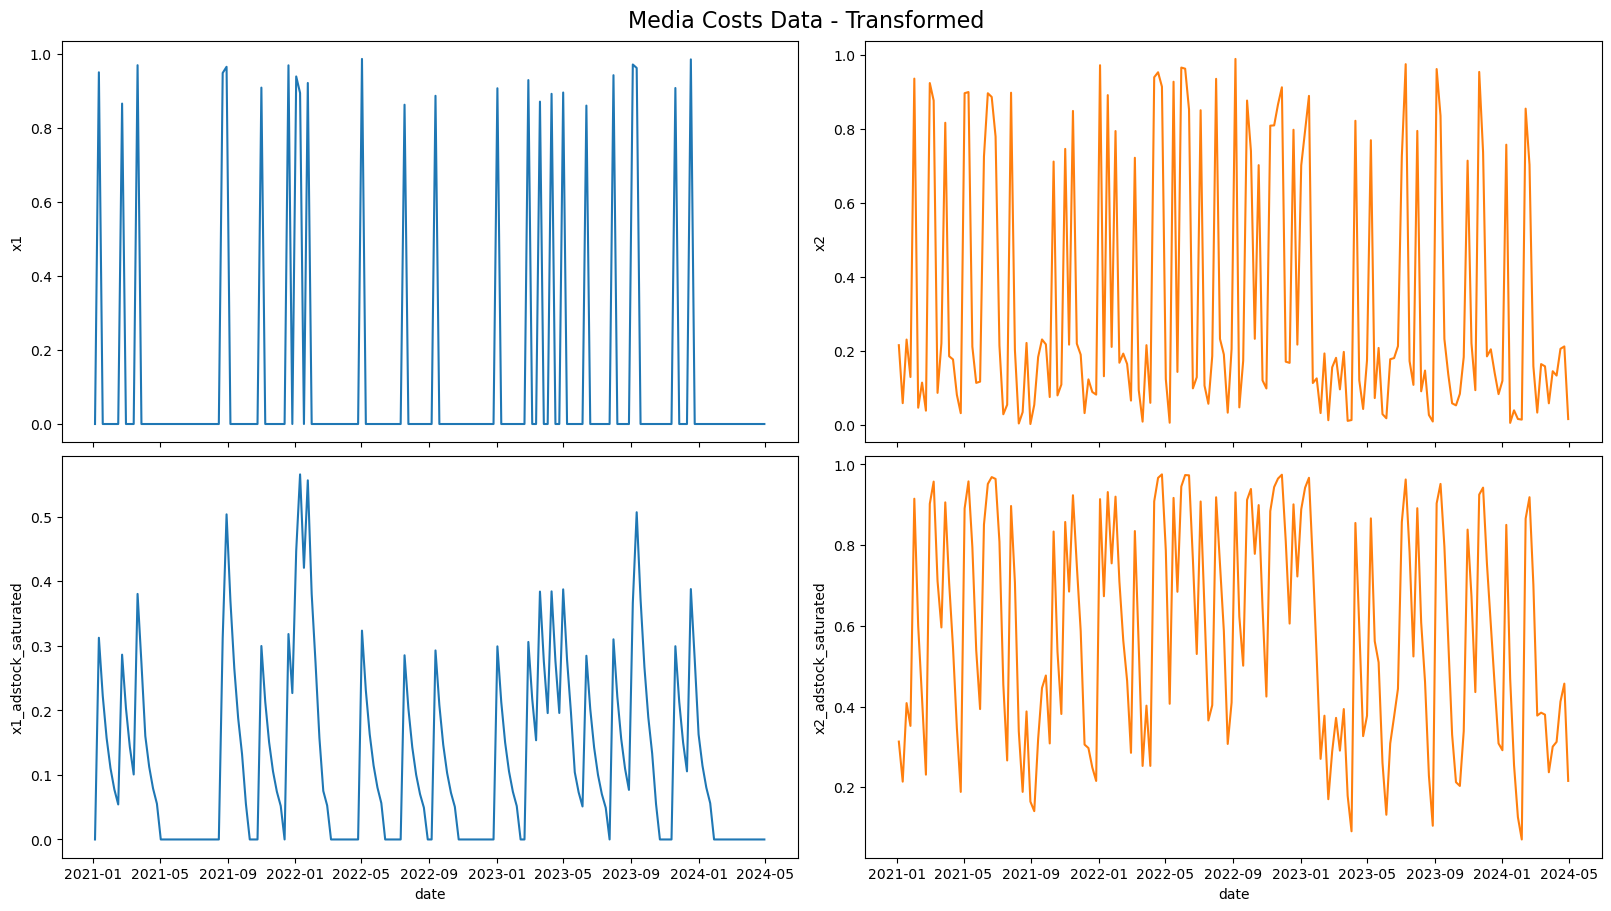

In [29]:
fig, ax = plt.subplots(
    nrows=2, ncols=2, figsize=(16, 9), sharex=True, sharey=False, layout="constrained"
)
sns.lineplot(x="date", y="x1", data=df, color="C0", ax=ax[0, 0])
sns.lineplot(x="date", y="x2", data=df, color="C1", ax=ax[0, 1])
#sns.lineplot(x="date", y="x1_adstock", data=df, color="C0", ax=ax[1, 0])
#sns.lineplot(x="date", y="x2_adstock", data=df, color="C1", ax=ax[1, 1])
sns.lineplot(x="date", y="x1_adstock_saturated", data=df, color="C0", ax=ax[1, 0])
sns.lineplot(x="date", y="x2_adstock_saturated", data=df, color="C1", ax=ax[1, 1])
fig.suptitle("Media Costs Data - Transformed", fontsize=16);

In [31]:
def generate_sales_data_final_df(df, betas, alphas):
    # this function outputs the completed dataframe as it uses all the features created in the previous functions to add the target variable: sales
    # assumption: demand is equal to sales; however, each marketing channel also contributes to sales 
    # betas is a list of the impact each marketing channel contributes to sales
    ### alphas represents the impact of the control events (control events not utilized as unsure how to calculate how it impacts demand)
    df['demand'] = df['trend'] + 0.2 * df['gdp_scaled'] + np.random.normal(loc=0.0, scale=0.25, size=len(df)) # represents in thousands 
    for j in np.arange(1, len(alphas) + 1):
        df['demand'] += df[f"event_{j}"] * alphas[j-1] # control events impact demand                                                                                                         # added random noise to represent peaks and dips in demand
    #df['demand'] += df['seasonality']
    df['demand_proxy'] = np.abs(df["demand"]* np.random.normal(loc=1, scale=0.15, size=len(df)))
    # in reality, i would calculate a proxy for demand by researching google search numbers over time as an indicator 
    # or clicks on that product on a website. 
    # that is why i am adding random noise to indicate that it is an estimate 
    df['sales'] = df['demand'] + df['seasonality'] 
    for i in np.arange(1, len(betas) + 1):
        df[f"x{i}_sales"] = df[f"x{i}_adstock_saturated"] * betas[i-1]
        df['sales'] += df[f"x{i}_sales"]

    cols_to_keep.append('sales')
    cols_to_keep.append('demand_proxy')
    return df

In [33]:
df = generate_sales_data_final_df(df, [3.0, 4.0], [2.0, 2.5])
df.head()

,date,event_1,event_2,gdp,gdp_scaled,trend,seasonality,x1,x2,x1_adstock,x2_adstock,x1_adstock_saturated,x2_adstock_saturated,demand,demand_proxy,sales,x1_sales,x2_sales
0,2021-01-04,1.0,0.0,21.984121,0.000000,0.778279,0.000000,0.000000,0.215058,0.000000,0.129565,0.000000,0.313041,3.138598,2.524467,4.390761,0.000000,1.252164
1,2021-01-11,0.0,0.0,22.065142,0.011239,0.791494,0.030134,0.950714,0.058122,0.323244,0.086843,0.312437,0.213759,0.434776,0.478450,2.257257,0.937310,0.855036
2,2021-01-18,0.0,0.0,22.074004,0.012469,0.804423,0.059829,0.000000,0.230313,0.226271,0.173493,0.222486,0.408436,1.097707,1.158070,3.458739,0.667459,1.633744
3,2021-01-25,0.0,0.0,22.120371,0.018901,0.817079,0.088651,0.000000,0.128912,0.158389,0.147062,0.157078,0.351940,0.823418,0.707331,2.791062,0.471234,1.407759
4,2021-02-01,0.0,0.0,22.096681,0.015615,0.829477,0.116181,0.000000,0.936730,0.110873,0.623175,0.110420,0.915085,0.587223,0.541959,4.695007,0.331261,3.660342


The graph below represents how demand_proxy is an actual proxy for demand.

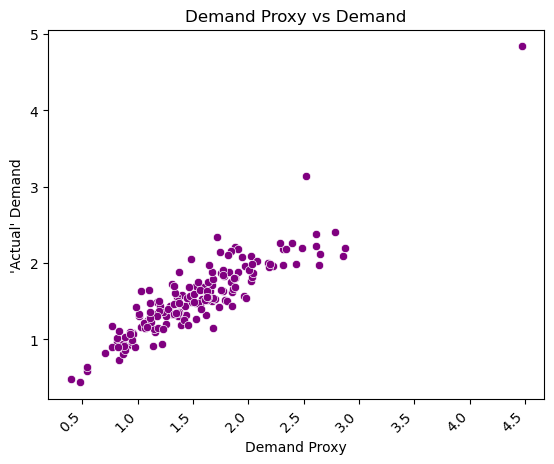

In [36]:
fig, ax = plt.subplots()
sns.scatterplot(x=df['demand_proxy'], y=df['demand'], color='purple')
ax.set(title="Demand Proxy vs Demand", xlabel="Demand Proxy", ylabel="'Actual' Demand")
plt.xticks(rotation=45, ha='right');

Below is a graph of our target variable, sales, over time. 

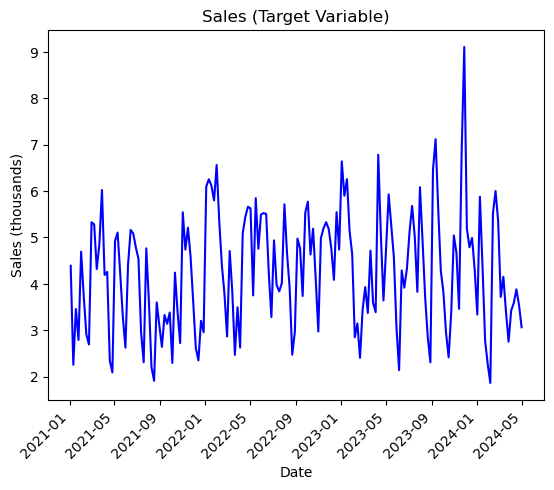

In [39]:
fig, ax = plt.subplots()
sns.lineplot(x="date", y="sales", color="blue", data=df, ax=ax)
ax.set(title="Sales (Target Variable)", xlabel="Date", ylabel="Sales (thousands)")
plt.xticks(rotation=45, ha='right');

##### Below is some further EDA, but since I created the data myself, I already have a pretty solid understanding of the data!

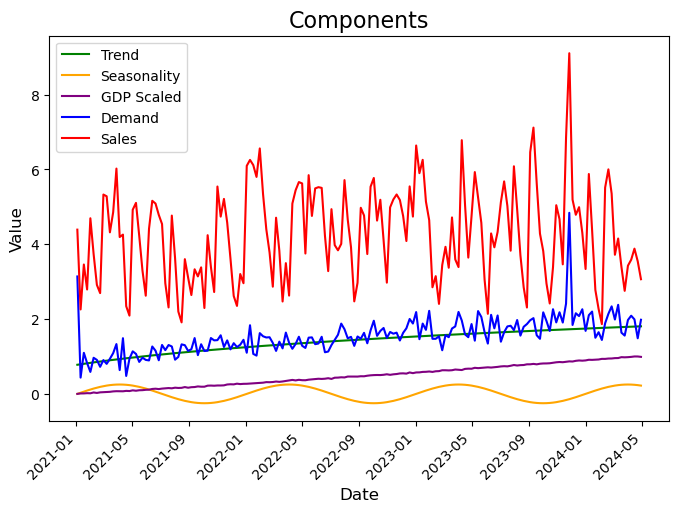

In [42]:
plt.figure(figsize=(8, 5))

sns.lineplot(x=df['date'], y=df['trend'], label="Trend", color="green")
sns.lineplot(x=df['date'], y=df['seasonality'], label="Seasonality", color="orange")
sns.lineplot(x=df['date'], y=df['gdp_scaled'], label="GDP Scaled", color="purple")
sns.lineplot(x=df['date'], y=df['demand'], label="Demand", color="blue")
#sns.lineplot(x=df['date'], y=df['demand_proxy'], label="Demand Proxy", color="pink")
sns.lineplot(x=df['date'], y=df['sales'], label="Sales", color="red")

plt.title('Components', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Value', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.show()

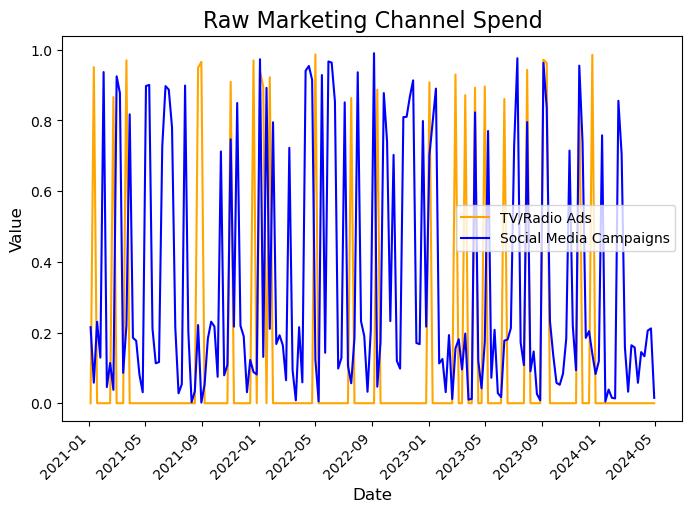

In [44]:
plt.figure(figsize=(8, 5))

sns.lineplot(x=df['date'], y=df['x1'], label="TV/Radio Ads", color="orange")
sns.lineplot(x=df['date'], y=df['x2'], label="Social Media Campaigns", color="blue")
plt.title('Raw Marketing Channel Spend', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Value', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.show()

### Objective 2

Build a Bayesian MMM using the synthetic data.

In [47]:
# features to be used for modeling
data = df[cols_to_keep].copy()
data.head()

,date,x1,x2,sales,demand_proxy
0,2021-01-04,0.000000,0.215058,4.390761,2.524467
1,2021-01-11,0.950714,0.058122,2.257257,0.478450
2,2021-01-18,0.000000,0.230313,3.458739,1.158070
3,2021-01-25,0.000000,0.128912,2.791062,0.707331
4,2021-02-01,0.000000,0.936730,4.695007,0.541959


In [49]:
# since channel contributions should be positive, I am going to use a HalfNormal distribution as the prior (essentially a normal distribution curve cut in half)
def calculate_sigma(data):
    channels = [col for col in data.columns if col.startswith('x')]
    n_channels = len(channels)
    total_spend_per_channel = data[channels].sum(axis=0)
    spend_share = total_spend_per_channel / total_spend_per_channel.sum() 
    prior_sigma = n_channels * spend_share.to_numpy()
    print(f"spend_share: {spend_share}")
    print(f"prior_sigmas respectively: {prior_sigma.tolist()}")
    return prior_sigma.tolist()

sigmas = calculate_sigma(data)

spend_share: x1    0.27398
x2    0.72602
dtype: float64
prior_sigmas respectively: [0.5479603540294635, 1.4520396459705365]


##### Training the model
splitting data into train and test split
and building the MMM

In [52]:
def train_test_split(df, train_size=0.7):
    df.sort_values(by='date')
    train_df = df[:int(len(data) * train_size)]
    test_df = df[int(len(data) * train_size):]
    X_train = train_df.drop('sales', axis=1)
    y_train = train_df['sales']
    X_test = test_df.drop('sales', axis=1)
    y_test = test_df['sales']
    return X_train, y_train, X_test, y_test

In [54]:
X_train, y_train, X_test, y_test = train_test_split(data) 
X_train.shape 

(121, 4)

In [56]:
y_train.shape

(121,)

In [58]:
X_test.shape

(53, 4)

In [60]:
y_test.shape

(53,)

In [62]:
data.shape

(174, 5)

In [64]:
def create_mmm_model(df, config, lag_max=6, yearly_seasonality=2):
    # want to see progress as the model trains
    sampler_config= {"progressbar": True}

    channel_vars = [col for col in data.columns if col.startswith('x')]
    print(f"Channel Columns: {[x for x in channel_vars]}")
    
    control_vars = ['demand_proxy']
    print(f"Control Columns: {[x for x in control_vars]}")

    mmm_model = MMM(
        date_column = "date",
        channel_columns = channel_vars,
        adstock = GeometricAdstock(l_max=lag_max),
        saturation = LogisticSaturation(),
        control_columns = control_vars,
        model_config = config,
        sampler_config = sampler_config,
        yearly_seasonality = yearly_seasonality
    )
    return mmm_model

In [66]:
my_config = {
        "saturation_beta": Prior("HalfNormal", sigma = sigmas),
        'gamma_control': Prior("Normal", mu=0, sigma=5, dims="control")#,   Give marketing more room
        #'adstock_alpha': Prior("Beta", alpha=2, beta=2, dims="channel"),  # More flexible lag structure
        #'saturation_lam': Prior("Gamma", alpha=2, beta=0.5, dims="channel"),  # Allow higher saturation
        ## commented out lines utilize default configurations but are examples of how to tune the model based off prior knowledge
    }

In [68]:
# actually building the model
my_mmm = create_mmm_model(data, my_config)
my_mmm.model_config

Channel Columns: ['x1', 'x2']
Control Columns: ['demand_proxy']


{'intercept': Prior("Normal", mu=0, sigma=2),
 'likelihood': Prior("Normal", sigma=Prior("HalfNormal", sigma=2)),
 'gamma_control': Prior("Normal", mu=0, sigma=5, dims="control"),
 'gamma_fourier': Prior("Laplace", mu=0, b=1, dims="fourier_mode"),
 'adstock_alpha': Prior("Beta", alpha=1, beta=3, dims="channel"),
 'saturation_lam': Prior("Gamma", alpha=3, beta=1, dims="channel"),
 'saturation_beta': Prior("HalfNormal", sigma=[0.54796035 1.45203965], dims="channel")}

Sampling: [adstock_alpha, gamma_control, gamma_fourier, intercept, saturation_beta, saturation_lam, y, y_sigma]


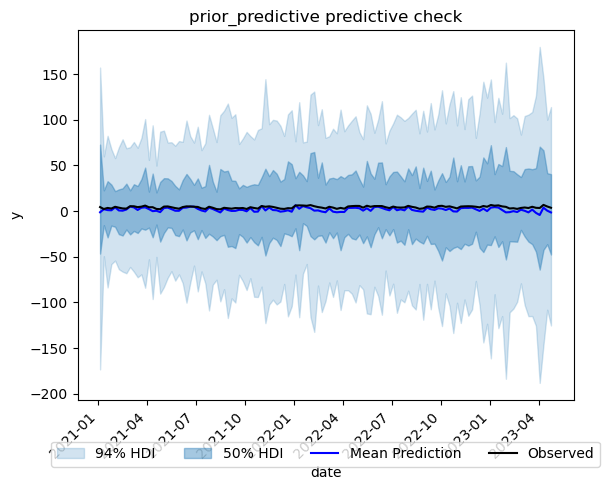

In [70]:
# Generate prior predictive samples
my_mmm.sample_prior_predictive(X_train, y_train, samples=2_000)

fig, ax = plt.subplots()
my_mmm.plot_prior_predictive(ax=ax, original_scale=True)
ax.legend(loc="lower center", bbox_to_anchor=(0.5, -0.2), ncol=4)
plt.xticks(rotation=45, ha='right');

This graph represents a prior predictive check. 94% HDI is the range covering 94% HDI (high density interval) of predicted values and 50% HDI covers 50%. Since these ranges are quite large, there is significant uncertainty within our prior meaning our prior is quite uninformative. However, since the mean prediction line and observed line are close to each other and have a lot of overlap, my priors are well-calibrated.

In [72]:
fit_kwargs = {
    "tune": 1_000, # this step always the model to explore the posterior distribution and these first (in this case) 1000 samples are not used for inference
    "chains": 2, # number of Markov chains to run in order to assess convergence
    "draws": 1_000, # number of samples to draw from posterior per chain
    "target_accept": 0.75, # helps balance exploration and efficiency; i lowered this value as i am working on my local computer and can't implement
                           # techniques such as GPU or core utilization in order to reach convergence faster (that's why i am only using 2 markov chains too)
}

In [76]:
my_mmm.fit(X_train, y_train, **fit_kwargs)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [intercept, adstock_alpha, saturation_lam, saturation_beta, gamma_control, gamma_fourier, y_sigma]


Output()

Sampling 2 chains for 1_000 tune and 1_000 draw iterations (2_000 + 2_000 draws total) took 11 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics


Inference data with groups:
	> posterior
	> sample_stats
	> prior
	> prior_predictive
	> observed_data
	> constant_data
	> fit_data

### Objective 3 

Validating the model and investigating key insights including running a budget optimization scenario.

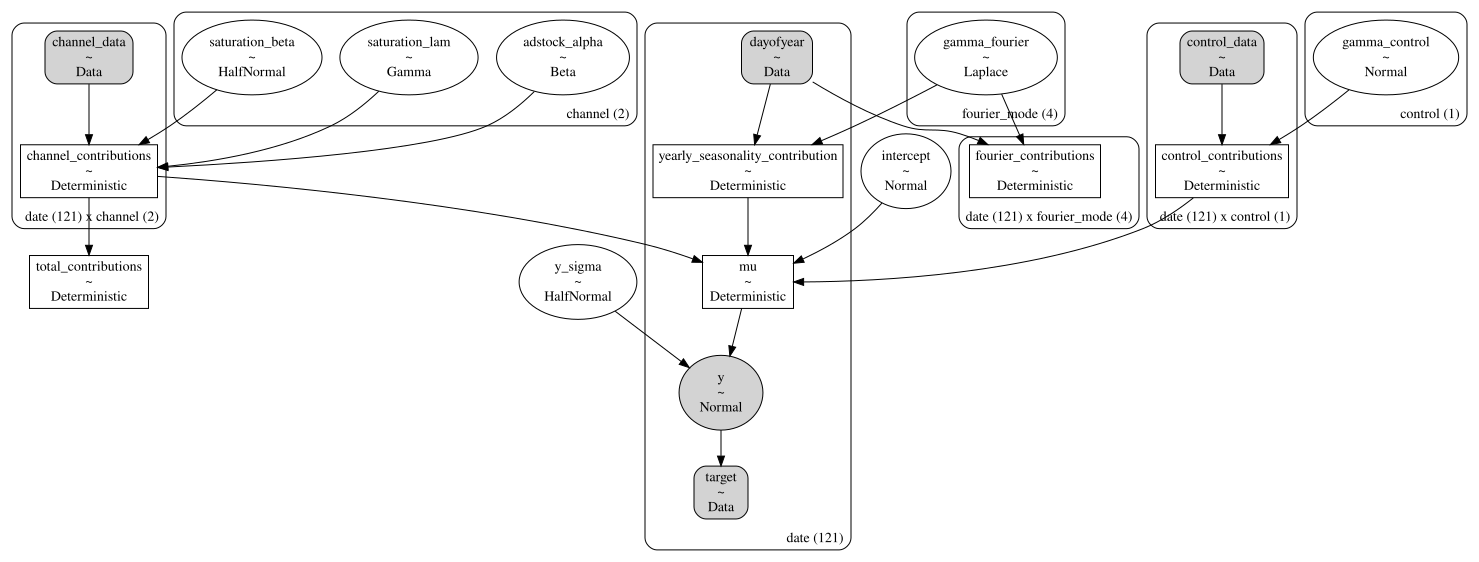

In [79]:
# represents DAG (directed acyclic graph)
# shows relationships within the model and how the pipeline is constructed
my_mmm.graphviz()

In [81]:
my_mmm.fit_result

<xarray.Dataset> Size: 18MB
Dimensions:                          (chain: 2, draw: 1000, control: 1,
                                      fourier_mode: 4, channel: 2, date: 121)
Coordinates:
  * chain                            (chain) int64 16B 0 1
  * draw                             (draw) int64 8kB 0 1 2 3 ... 997 998 999
  * control                          (control) <U12 48B 'demand_proxy'
  * fourier_mode                     (fourier_mode) <U5 80B 'sin_1' ... 'cos_2'
  * channel                          (channel) <U2 16B 'x1' 'x2'
  * date                             (date) datetime64[ns] 968B 2021-01-04 .....
Data variables: (12/13)
    intercept                        (chain, draw) float64 16kB 0.0374 ... 0....
    gamma_control                    (chain, draw, control) float64 16kB 0.11...
    gamma_fourier                    (chain, draw, fourier_mode) float64 64kB ...
    adstock_alpha                    (chain, draw, channel) float64 32kB 0.65...
    saturation_lam                   (chain, draw, channel) float64 32kB 3.06...
    saturation_beta                  (chain, draw, channel) float64 32kB 0.28...
    ...                               ...
    channel_contributions            (chain, draw, date, channel) float64 4MB ...
    total_contributions              (chain, draw) float64 16kB 52.7 ... 52.07
    control_contributions            (chain, draw, date, control) float64 2MB ...
    fourier_contributions            (chain, draw, date, fourier_mode) float64 8MB ...
    yearly_seasonality_contribution  (chain, draw, date) float64 2MB -0.00379...
    mu                               (chain, draw, date) float64 2MB 0.5156 ....
Attributes:
    created_at:                 2025-02-12T18:39:34.445522+00:00
    arviz_version:              0.20.0
    inference_library:          pymc
    inference_library_version:  5.20.1
    sampling_time:              10.500880718231201
    tuning_steps:               1000

In [83]:
# Number of diverging samples
my_mmm.idata["sample_stats"]["diverging"].sum().item()

0

Divergence within a sample indicates there was trouble exploring the posterior distribution. Ideal number of divergences is 0, but a low number can still suggests the model is fitting well, parameters are being estimated effectively, and overall, reaching convergence. Let's check this further.

In [86]:
az.summary(my_mmm.fit_result)

/opt/anaconda3/lib/python3.12/site-packages/arviz/stats/diagnostics.py:596: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
/opt/anaconda3/lib/python3.12/site-packages/arviz/stats/diagnostics.py:596: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
/opt/anaconda3/lib/python3.12/site-packages/arviz/stats/diagnostics.py:596: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
/opt/anaconda3/lib/python3.12/site-packages/arviz/stats/diagnostics.py:596: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
/opt/anaconda3/lib/python3.12/site-packages/arviz/stats/diagnostics.py:596: RuntimeWarning: invalid value encountered in

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
intercept,0.035,0.014,0.009,0.062,0.0,0.0,1028.0,1223.0,1.0
gamma_control[demand_proxy],0.113,0.006,0.103,0.125,0.0,0.0,1254.0,1273.0,1.0
gamma_fourier[sin_1],0.032,0.004,0.025,0.039,0.0,0.0,1610.0,1233.0,1.0
gamma_fourier[sin_2],0.003,0.004,-0.004,0.011,0.0,0.0,1793.0,1637.0,1.0
gamma_fourier[cos_1],0.002,0.004,-0.005,0.009,0.0,0.0,1640.0,1331.0,1.0
...,...,...,...,...,...,...,...,...,...
mu[2023-03-27T00:00:00.000000000],0.505,0.009,0.487,0.520,0.0,0.0,1935.0,1627.0,1.0
mu[2023-04-03T00:00:00.000000000],0.524,0.014,0.498,0.550,0.0,0.0,1911.0,1048.0,1.0
mu[2023-04-10T00:00:00.000000000],1.004,0.010,0.986,1.024,0.0,0.0,1260.0,1388.0,1.0
mu[2023-04-17T00:00:00.000000000],0.724,0.008,0.708,0.738,0.0,0.0,1714.0,1538.0,1.0


In [88]:
az.summary(my_mmm.fit_result).r_hat.mean()

/opt/anaconda3/lib/python3.12/site-packages/arviz/stats/diagnostics.py:596: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
/opt/anaconda3/lib/python3.12/site-packages/arviz/stats/diagnostics.py:596: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
/opt/anaconda3/lib/python3.12/site-packages/arviz/stats/diagnostics.py:596: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
/opt/anaconda3/lib/python3.12/site-packages/arviz/stats/diagnostics.py:596: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
/opt/anaconda3/lib/python3.12/site-packages/arviz/stats/diagnostics.py:596: RuntimeWarning: invalid value encountered in

1.0000379146919431

Since r_hat is approximately 1 (r_hat measures convergence), the model is converging well.

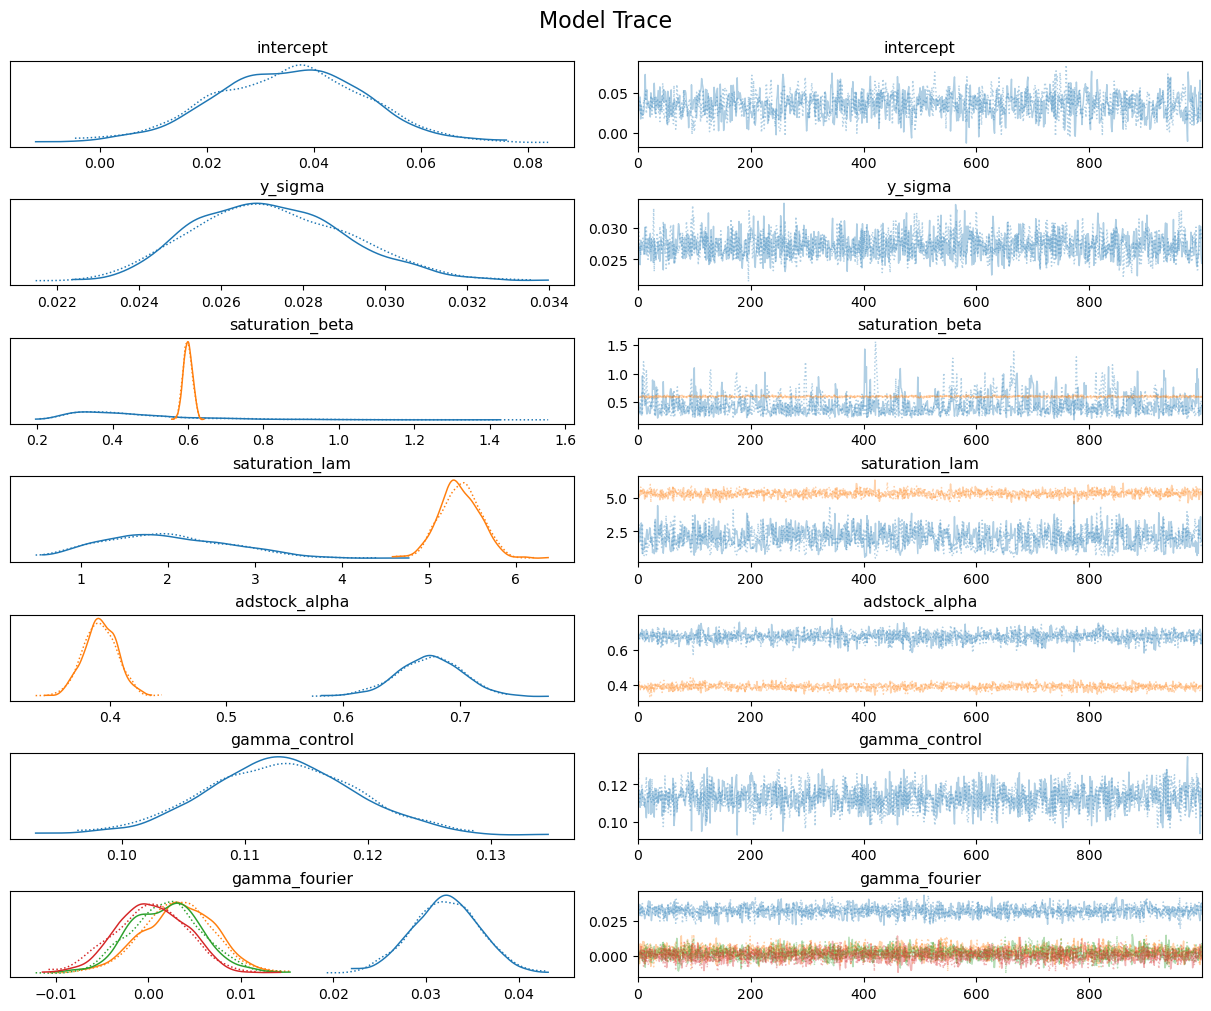

In [91]:
_ = az.plot_trace(
    data=my_mmm.fit_result,
    var_names=[
        "intercept",
        "y_sigma",
        "saturation_beta",
        "saturation_lam",
        "adstock_alpha",
        "gamma_control",
        "gamma_fourier",
    ],
    compact=True,
    backend_kwargs={"figsize": (12, 10), "layout": "constrained"},
)
plt.gcf().suptitle("Model Trace", fontsize=16);

# code taken from cited sources

In [93]:
az.summary(my_mmm.fit_result, var_names=["saturation_beta"])

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
saturation_beta[x1],0.458,0.179,0.221,0.790,0.007,0.005,737.0,721.0,1.0
saturation_beta[x2],0.600,0.012,0.579,0.624,0.000,0.000,1158.0,1195.0,1.0


In [95]:
az.summary(my_mmm.fit_result, var_names=["saturation_lam"])

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
saturation_lam[x1],1.987,0.701,0.764,3.242,0.025,0.018,740.0,769.0,1.0
saturation_lam[x2],5.359,0.231,4.942,5.779,0.007,0.005,1152.0,1549.0,1.0


In [97]:
az.summary(my_mmm.fit_result, var_names=["adstock_alpha"])

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
adstock_alpha[x1],0.674,0.028,0.618,0.724,0.001,0.001,1217.0,1203.0,1.0
adstock_alpha[x2],0.392,0.015,0.365,0.420,0.000,0.000,1258.0,1600.0,1.0


In [99]:
az.summary(my_mmm.fit_result, var_names=["gamma_control"])

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
gamma_control[demand_proxy],0.113,0.006,0.103,0.125,0.0,0.0,1254.0,1273.0,1.0


On the left, we have the posterior distribution of each parameter. Let's go over each variable one by one:
* The intercept is approximately unimodal and symmetric implying good convergence which confirms our validation findings earlier.
* y_sigma has a tight distribution suggesting that the model has learned the noise level caused by uncertainty well.
* x1 saturation beta is represented by the blue line and peaks at a relatively low level. This indicates a weak effect, whereas x2 saturation beta (orange line) has a tighter distribution and peaks at a higher level. This suggests x2 influences sales significantly more.
*  x1 saturation lambda is represented by the blue line again and has a skewed distribution that isn't tight. On the other hand, x2 saturation lambda has a sharp peak and a tight distribution suggesting the model learned well. Notice that both of these values are close to what values I inputted in the data generation step, showing the model learned well and was able to capture true values well. This is also true for adstock alpha values.
*  x1 and x2 adstock alpha values have sharp peaks and a tight distribution around their mean values, suggesting there is high certainty about how past marketing efforts of each channel contribute to sales.
*  gamma control for demand proxy has a tight distribution and is unimodal, suggesting that the impact of demand proxy is well captured.
*  There is one component of gamma fourier whose distribution does not overlap with the other 3, suggesting that there is pattern with this component and sales.
  
We can see the exploration steps on the right hand side and how the variance in each step of exploration contributes to how tight the distribution of each variable is.

In [102]:
# sample from posterior to predict sales based off X_train
y_train_pred = my_mmm.sample_posterior_predictive(X_train, extend_idata=True, combined=True);

Sampling: [y]


Output()

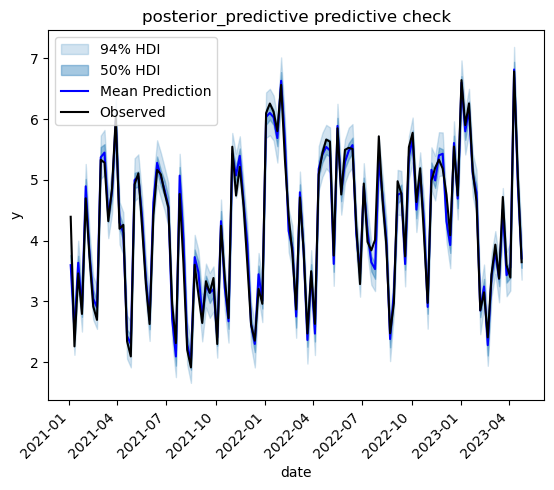

In [104]:
my_mmm.plot_posterior_predictive(original_scale=True)
plt.xticks(rotation=45, ha='right');

In [106]:
# r2 on training data
y_train_pred_mean = y_train_pred['y'].mean(dim='sample').values
r2_score(y_train, y_train_pred_mean)

0.9783695118226337

It appears that our model has performed well at estimating the true values given the high r2 score and plot. Let's dive further.

In [108]:
y_out_of_sample = my_mmm.sample_posterior_predictive(X_test, extend_idata=False, include_last_observations=True)

Sampling: [y]


Output()

In [110]:
lower, upper = quantiles = [0.025, 0.975]
conf = y_out_of_sample['y'].to_series().groupby("date").quantile(quantiles).unstack()

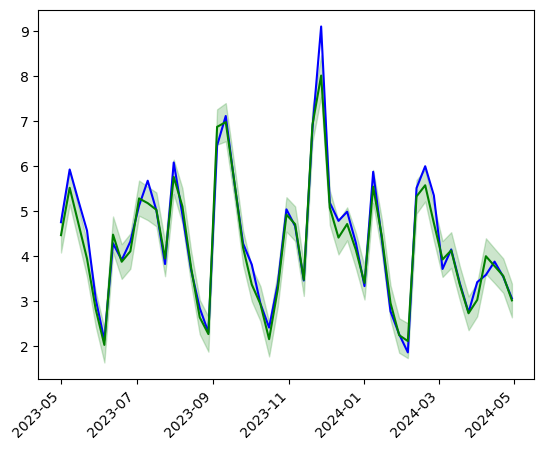

In [112]:
x = X_test["date"]
y = y_test
plt.plot(x, y, linestyle='-', color='b', label='Observed Sales')
plt.plot(x, y_out_of_sample['y'].to_series().groupby("date").mean().values, linestyle='-', color='g', label='Predicted Sales')
plt.fill_between(x, conf[0.025], conf[0.975], color='g', alpha=0.2)
plt.xticks(rotation=45, ha='right');

It appears that my model would still perform well with some variance on unseen data. Let's look at the residuals from the training data.

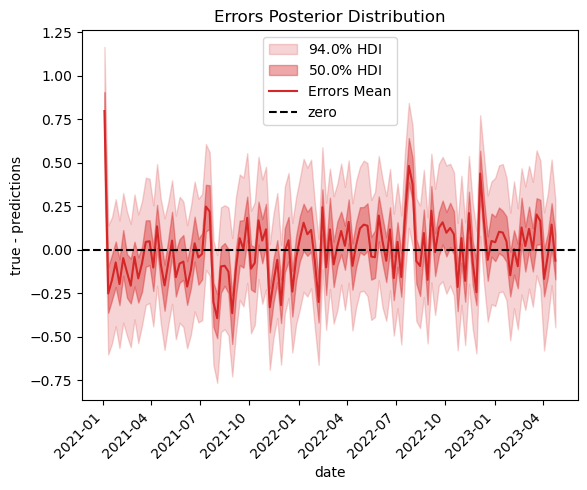

In [115]:
my_mmm.plot_errors(original_scale=True)
plt.xticks(rotation=45, ha='right');

It looks like the residuals oscillate around 0 and that there is no distinct pattern. 

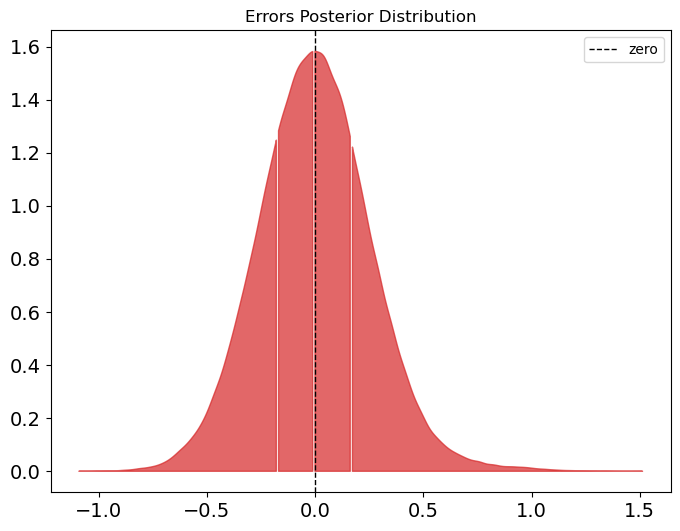

In [117]:
errors = my_mmm.get_errors(original_scale=True)

fig, ax = plt.subplots(figsize=(8, 6))
az.plot_dist(
    errors, quantiles=[0.25, 0.5, 0.75], color="C3", fill_kwargs={"alpha": 0.7}, ax=ax
)
ax.axvline(x=0, color="black", linestyle="--", linewidth=1, label="zero")
ax.legend()
ax.set(title="Errors Posterior Distribution");

The residuals are normally distributed around 0 implying that the errors are random scattered and the model fits the data well. 

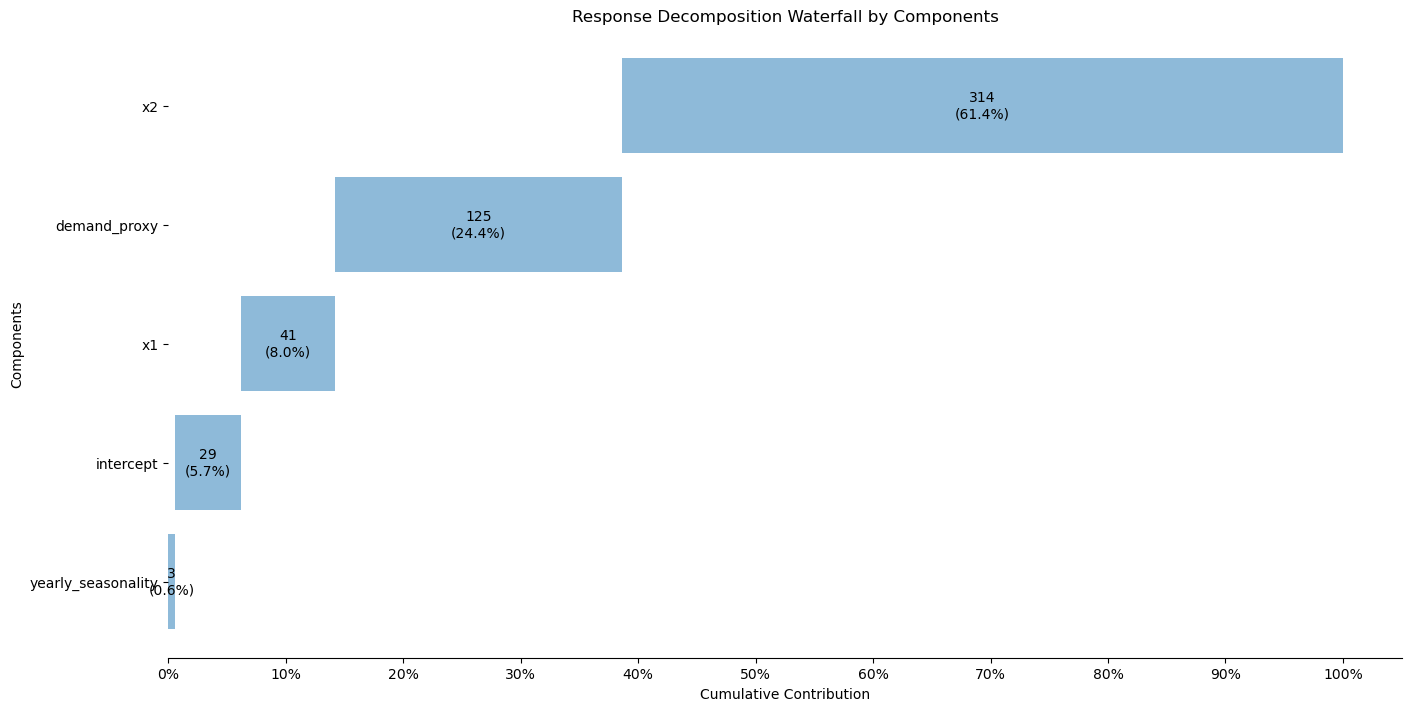

In [119]:
my_mmm.plot_waterfall_components_decomposition();

The historical contributions from x2 (social media campaigns) and demand_proxy (an estimate of demand)  seem to be the biggest contributors of sales, but especially x2 marketing channel. The intercept and x1 (tv/radio ads) have a smaller impact. There is some fluctation with yearly_seasonality but it is very minimal. 

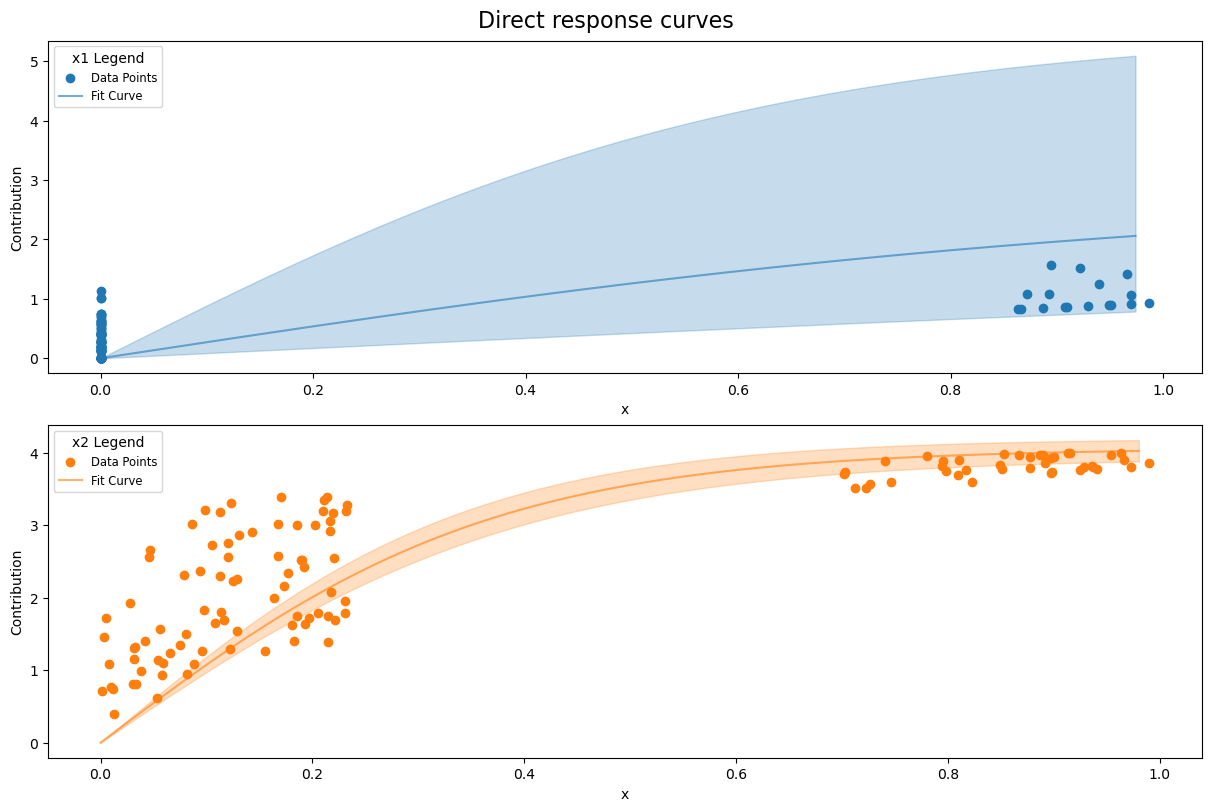

In [122]:
# the graphs below show where every week's spend falls on each channel's saturation curve
# this resembles the functions I created for x1 and x2 in generate_media_data function

fig = my_mmm.plot_direct_contribution_curves(show_fit=True)
[ax.set(xlabel="x") for ax in fig.axes];

Since I generated the data, I can do a deep dive into the posterior distributions.

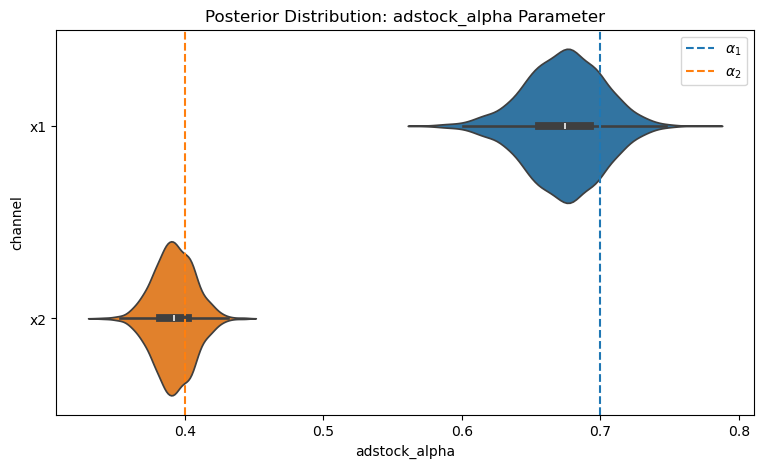

In [124]:
fig = my_mmm.plot_channel_parameter(param_name="adstock_alpha", figsize=(9, 5))
ax = fig.axes[0]
ax.axvline(x=0.7, color="C0", linestyle="--", label=r"$\alpha_1$") # represents true value of a1 in generate_media_data function
ax.axvline(x=0.4, color="C1", linestyle="--", label=r"$\alpha_2$") # represents true value of a2 in generate_media_data function
ax.legend(loc="upper right");

The distributions capture their respective true value. Their is a tighter distribution around the geometric adstock transformation for x2 marketing channel implying less variation in estimated posterior value. 

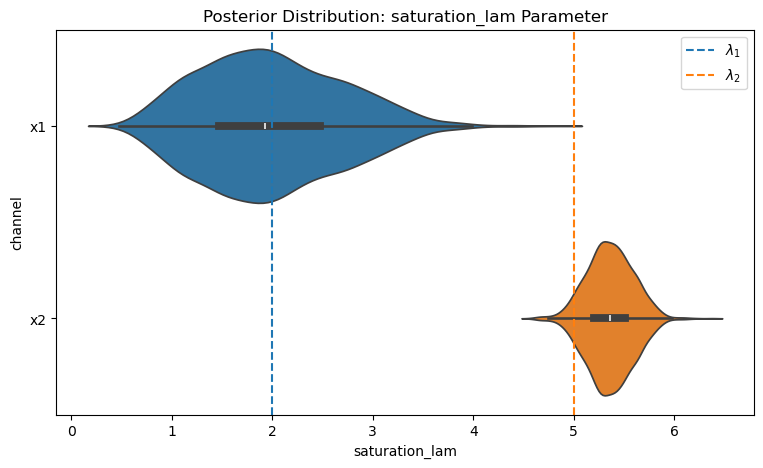

In [126]:
fig = my_mmm.plot_channel_parameter(param_name="saturation_lam", figsize=(9, 5))
ax = fig.axes[0]
ax.axvline(x=2.0, color="C0", linestyle="--", label=r"$\lambda_1$") # represents true value of l1 in generate_media_data function
ax.axvline(x=5.0, color="C1", linestyle="--", label=r"$\lambda_2$") # represents true value of l2 in generate_media_data function
ax.legend(loc="upper right");

Once again, the model's posterior distribution captures their respective true values pretty well; however, we can see their is significant variation with the lambda estimate for x1 marketing channel. A larger training data could help with this. 

Let's dive deeper into channel contributions.

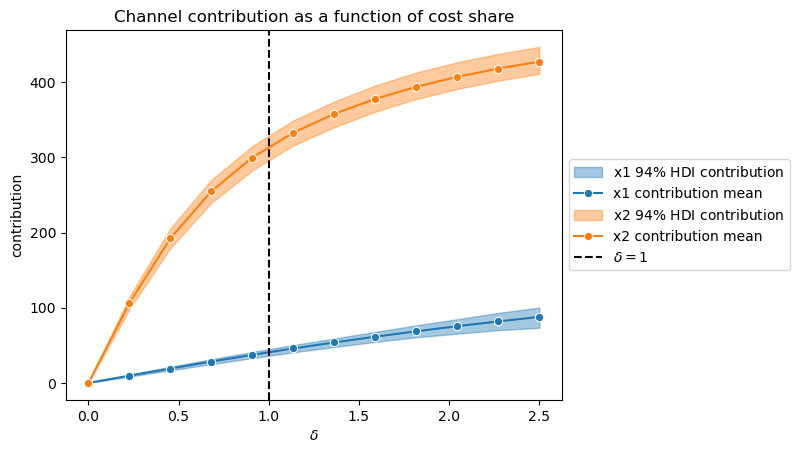

In [128]:
my_mmm.plot_channel_contributions_grid(start=0, stop=2.5, num=12);

The x-axis represents the percentage level of channel input. As seen in the plot, when there is 0 spend, there is no contribution. It seems that x1 marketing channel has diminishing returns to additional spending early on, whereas x1 marketing channel tapers off around x-axis = 1.5.

In [130]:
X = pd.concat([X_train, X_test])
X

,date,x1,x2,demand_proxy
0,2021-01-04,0.000000,0.215058,2.524467
1,2021-01-11,0.950714,0.058122,0.478450
2,2021-01-18,0.000000,0.230313,1.158070
3,2021-01-25,0.000000,0.128912,0.707331
4,2021-02-01,0.000000,0.936730,0.541959
...,...,...,...,...
169,2024-04-01,0.000000,0.144617,1.641378
170,2024-04-08,0.000000,0.132835,2.856218
171,2024-04-15,0.000000,0.205283,2.029659
172,2024-04-22,0.000000,0.211698,1.510093


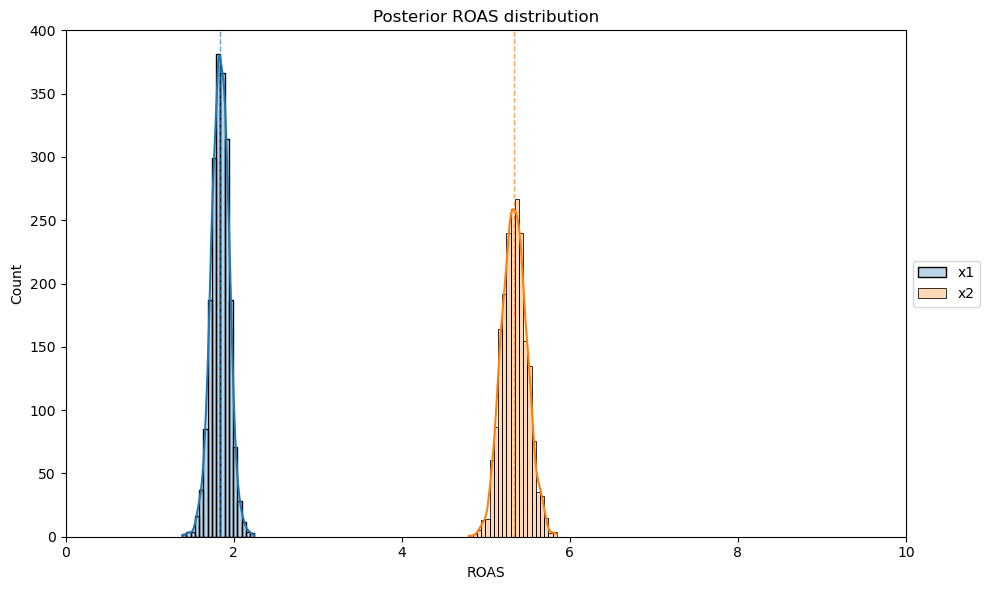

In [132]:
channel_contribution_original_scale = my_mmm.compute_channel_contribution_original_scale()
spend_sum = X[["x1", "x2"]].sum().to_numpy()

roas_samples = (
    channel_contribution_original_scale.stack(sample=("chain", "draw")).sum("date")
    / spend_sum[..., None]
)

fig, ax = plt.subplots(figsize=(10, 6))
for channel in ["x1", "x2"]:
    data = roas_samples.sel(channel=channel).to_numpy()
    histplot = sns.histplot(data, label=channel, binwidth=0.05, alpha=0.3, kde=True, ax=ax)
    color = ax.lines[-1].get_color()

    # Calculate and display mean for each channel
    median_value = np.median(data)
    ax.axvline(median_value, linestyle='dashed', color=color, alpha=0.7, linewidth=1)

ax.set_xlim(0,10)
ax.legend(loc="center left", bbox_to_anchor=(1, 0.5))
ax.set(title="Posterior ROAS distribution", xlabel="ROAS")
plt.tight_layout()
# code modified from resources cited at the end 

In [134]:
#let's get one number for ROAS for each channel
roas_samples.median(dim='sample').to_dataframe(name='median_ROAS').sort_values(by='median_ROAS',ascending=False)

,median_ROAS
channel,
x2,5.335518
x1,1.837149


From the graph and the median ROAS for each channel, it can be confirmed that x2 marketing channel is more efficient at increasing sales even with uncertainty.

##### BUDGET OPTIMIZATION SCENARIO
Company X that owns this product has 1M over 4 weeks to spend on marketing to maximize sales. 

In [136]:
budget = 1 # 1 mil USD
channels = ['x1', 'x2']
timeline = 4 # 4 weeks 

# intial split
budget_per = budget / len(channels)
budget_dict = {channel: budget_per for channel in channels}

# bounds
min_spend = 0.01
max_spend = 0.99
budget_bounds = {channel: [min_spend, max_spend] for channel in channels}

In [138]:
model_granularity = "weekly"
allocation_strategy, optimization_result = my_mmm.optimize_budget(
    budget=budget,
    num_periods=timeline,
    budget_bounds=budget_bounds,
)

response = my_mmm.sample_response_distribution(
    allocation_strategy=allocation_strategy,
    time_granularity=model_granularity,
    num_periods=timeline,
    noise_level=0.01,
)

/opt/anaconda3/lib/python3.12/site-packages/pymc_marketing/mmm/budget_optimizer.py:215: UserWarning: Using default equality constraint
  self.set_constraints(


In [139]:
print("\n=== Budget Allocation Summary ===\n")
for channel, budget in response.allocation.to_dataframe().iterrows():
    print(f"Channel {channel:>2}: {budget['allocation']:>8.2f}M")
print("\n" + "-" * 30)
print(f"Total Budget: {sum(response.allocation.to_numpy()):>8.2f}M")
print("-" * 30)


=== Budget Allocation Summary ===

Channel x1:     0.29M
Channel x2:     0.71M

------------------------------
Total Budget:     1.00M
------------------------------


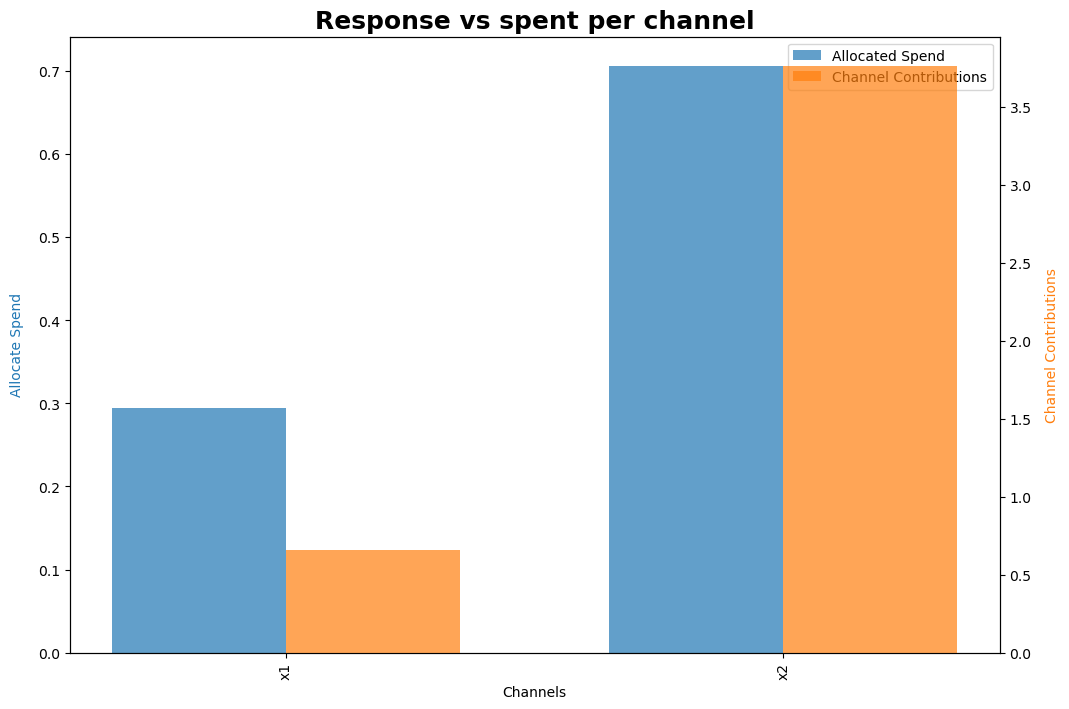

In [142]:
fig, ax = my_mmm.plot_budget_allocation(samples=response, figsize=(12, 8))
ax.set_title("Response vs spent per channel", fontsize=18, fontweight="bold");

#### Summary of Insights and Recommendations

##### Model Review
The model I built takes in 2 different marketing channels - one that represents ads targeting a broader audience and the other representing social media ads that have a more targeted audience. This model also uses a proxy/estimate for demand as control variables. In a more refined project, demand can be estimated through prior knowledge on search trends, competitor sales analysis, etc. I also incorporated some seasonality into the model. Furthermore, I adjusted the model's prior to fit marketing channels data better because marketing seems to have a big effect on sales in my synthetic data (as can be seen in comparing the demand line and sales line in the graph below) (this is most likely due to the beta values I picked for each marketing channel). The model learned from the training set well and performs well on both the training data and test data as confirmed by the metrics calculated before. 

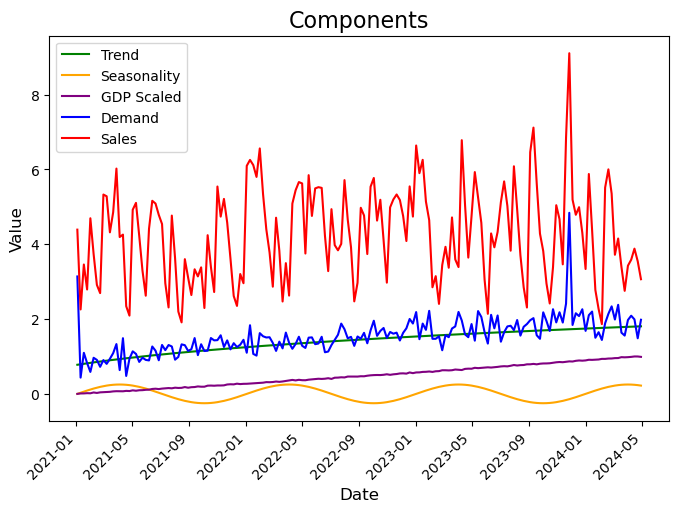

In [145]:
plt.figure(figsize=(8, 5))

sns.lineplot(x=df['date'], y=df['trend'], label="Trend", color="green")
sns.lineplot(x=df['date'], y=df['seasonality'], label="Seasonality", color="orange")
sns.lineplot(x=df['date'], y=df['gdp_scaled'], label="GDP Scaled", color="purple")
sns.lineplot(x=df['date'], y=df['demand'], label="Demand", color="blue")
#sns.lineplot(x=df['date'], y=df['demand_proxy'], label="Demand Proxy", color="pink")
sns.lineplot(x=df['date'], y=df['sales'], label="Sales", color="red")

plt.title('Components', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Value', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.show()

##### Channel Contributions

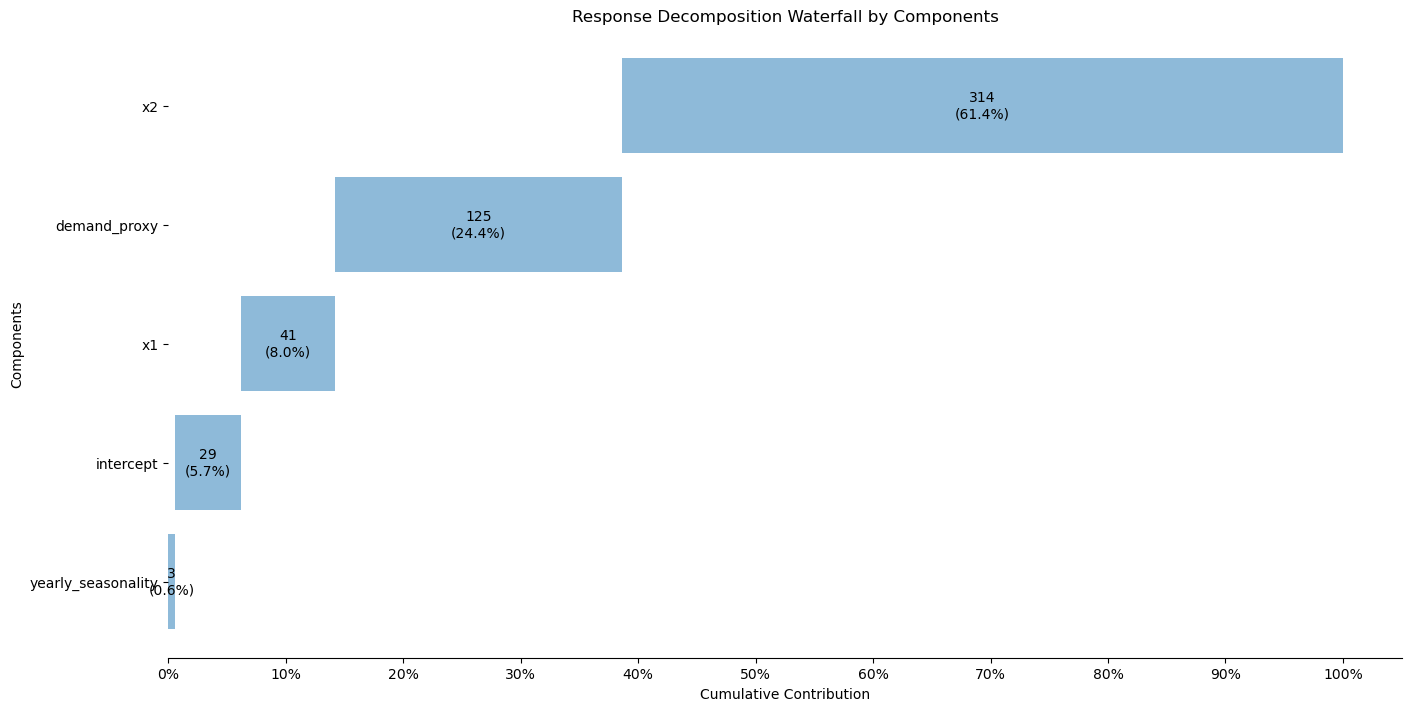

In [147]:
my_mmm.plot_waterfall_components_decomposition();

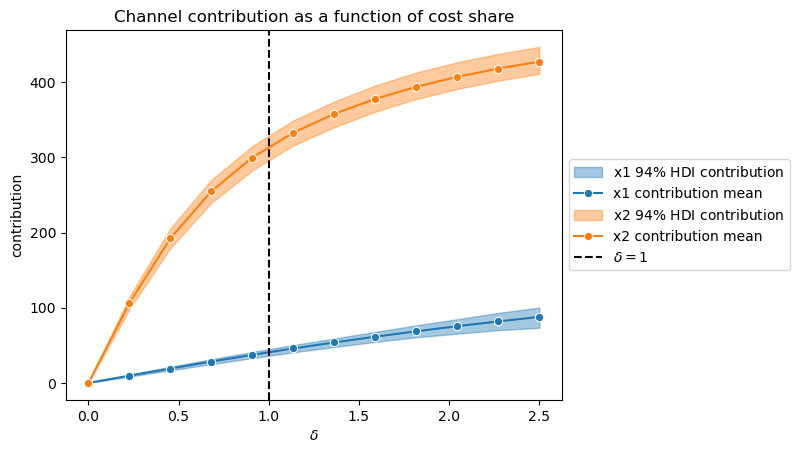

In [150]:
my_mmm.plot_channel_contributions_grid(start=0, stop=2.5, num=12);

It is clear from the that x2 marketing channel (social media) has a significant impact and the greatest impact on generating sales. It accounts for ~62% of total paid media contribution. From the last graph, we can see that there are significant diminshing returns with x1 marketing channel (tv/radio ads) and this channel already has a low impact on sales. This indicates more effort should be spent on x2 marketing channel and the graph directly above shows by eyeballing, we can increase spending by approximately 50% to reach an optimal level of exposure and thus, contribution. 

##### ROAS (Return on Ad Spend)

In [152]:
roas_samples.mean(dim='sample').to_dataframe(name='mean_ROAS').sort_values(by='mean_ROAS',ascending=False)

,mean_ROAS
channel,
x2,5.337772
x1,1.835455


Return on ad spend was highest for x2 marketing channel (social media) which makes sense as it has a greater contribution to sales. Based off the statistics above, for every \\$1 spent on this marketing channel, the return was approximately \\$5.34 in revenue on average and for every \\$1 spent on x1 marketing channel (tv/radio ads), the return was approximately \\$1.84 in revenue on average. This is good to know because we are not operating at a loss with either marketing channel efforts and combining this with the graph, Channel Contribution as a Function of Cost Share, it can be seen that the contribution from each channel has minimal variation, further confirming we are not operating at a loss.

##### Budget Optimization

In [155]:
print("\n=== Budget Allocation Summary ===\n")
for channel, budget in response.allocation.to_dataframe().iterrows():
    print(f"Channel {channel:>2}: {budget['allocation']:>8.2f}M")
print("\n" + "-" * 30)
print(f"Total Budget: {sum(response.allocation.to_numpy()):>8.2f}M")
print("-" * 30)


=== Budget Allocation Summary ===

Channel x1:     0.29M
Channel x2:     0.71M

------------------------------
Total Budget:     1.00M
------------------------------


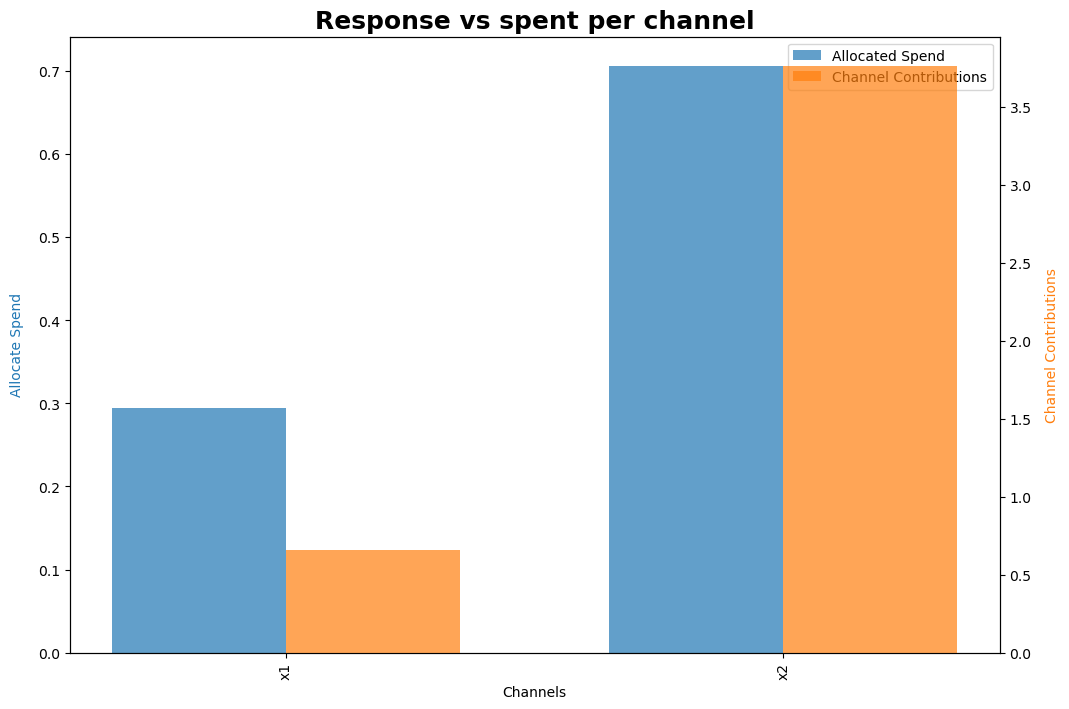

In [157]:
fig, ax = my_mmm.plot_budget_allocation(samples=response, figsize=(12, 8))
ax.set_title("Response vs spent per channel", fontsize=18, fontweight="bold");

Based off the budget optimization scenario I created earlier, for a total budget of $1 million USD to be used in 4 weeks, x1 marketing channel budget allocation should be 0.29 million USD and x2 marketing channel budget allocation should be 0.71 million USD. However, we can see that x1 will have lower contribution rate for ad spending than x2's contribution rate. However, this does not mean we should put more money into x2 marketing efforts as our model is also accounting for carryover and saturation effects.

##### Summary for Nontechnical Stakeholders

Using PyMC, I contructed a Bayesian Mixed Media Model to understand the marketing efforts around the product owned by Company X looking across the time period from Jan 1, 2021 to May 1, 2024. Here are some key insights and actionable recommendations:
* Social media marketing channels have the greatest contribution to generating sales and increasing revenue. The return on ad spend for this marketing channel is estimated to be \\$5.34 for every dollar in ad spend on average. For a budget of \\$1 million in marketing, 71% of it should be invested into social media campaigns for optimal efficiency.
* The other marketing channel focusing on tv and radio ads does not generate loss. In fact, the average return on ad spend is \\$1.84, thus 29% of total marketing budget should be invested into this channel. However, it is not reasonable to expect the same level of impact on revenue as social media marketing channels.

### Objective 4
Package model as an example for PyPI and go over how this would be deployed in production.

In [161]:
url_to_package = 'https://test.pypi.org/project/bayesianmmm/'

In [170]:
!pip3 install -i https://test.pypi.org/simple/ bayesianmmm==1.3.2

Looking in indexes: https://test.pypi.org/simple/


In [172]:
!pip3 show bayesianmmm

Name: bayesianmmm
Version: 1.3.2
Summary: Generates synthetic marketing and sales data and trains a PyMC Bayesian MMM
Home-page: https://github.com/sairachawla/bayesianmmm
Author: Saira Chawla
Author-email: sc5119@columbia.edu
License: 
Location: /opt/anaconda3/lib/python3.12/site-packages
Requires: arviz, matplotlib, numpy, pandas, pymc-marketing, seaborn
Required-by: 


In [178]:
my_mmm.save("my_saved_model.nc")

Since the key objective of this project was to package and deploy the MMM model, I structured my approach by functionalizing the data and model generation steps, making them reusable and adaptable to user preferences and prior knowledge. The bayesianmmm package encapsulates these steps, providing an installable solution for generating synthetic data and training Bayesian MMMs.

However, in a production environment, packaging and deployment would require a combination of Docker and AWS SageMaker for scalability, reproducibility, and automation.

Model & Environment Preparation
* The model would ingest data from an S3 bucket.
* A preprocessing function would clean and transform data before training.
  
Containerization with Docker
* A Dockerfile would define the environment, installing dependencies, and setting up the inference script.
* The script would be modified to save generated synthetic data to an S3 bucket and allow updates or modifications to the dataset.
* A separate script would handle model training and saving based on the data stored in S3.
* Another script would validate model performance and generate insights/recommendations.

Model Deployment & Versioning
* The Docker image would be built and tested locally before being pushed to AWS Elastic Container Registry (ECR) for version control.
* AWS SageMaker Training Jobs would be scheduled for automated model retraining.
* Model versions and performance would also be stored using MLflow for tracking and management.

Inference & Monitoring
* The deployed model would be hosted via SageMaker Endpoints or an API-based solution using ECS + Lambda.
* A custom performance monitoring script would evaluate model effectiveness, with logs and insights stored in CloudWatch or S3.
  
This approach ensures a scalable, reproducible, and automated deployment pipeline, allowing for seamless model updates and efficient inference. 

Resources:

https://towardsdatascience.com/mastering-marketing-mix-modelling-in-python-7bbfe31360f9/
https://www.pymc-marketing.io/en/stable/guide/index.html
https://www.pymc-marketing.io/en/stable/notebooks/mmm/mmm_example.html#feature-engineering